# *****Performance Prediction Model*****

Model memprediksi **11 statistik profil pemain sekaligus** dari 1 vektor sesi menggunakan `MultiOutputRegressor`

| Input X (8 fitur) | Output Y (11 target) |
|---|---|
| tpc, er, hr, cr, nmr, gur, moves, score | exp_tpc, exp_er, exp_hr, exp_cr, exp_nmr, exp_gur, exp_score, speed_idx, accuracy_idx, consistency_idx, independence_idx |

In [1]:
import numpy as np
import pandas as pd
import json, os, pickle, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

In [2]:
# Naming & Grouping
FEATURE_NAMES = ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'moves', 'score']
FEATURE_DESC  = [
    'Time-per-cell (s)', 'Error rate/move', 'Hint rate/move',
    'Completion rate', 'Near-miss rate', 'Guessing rate',
    'Avg moves', 'Score'
]
TARGET_NAMES = [
    'exp_tpc', 'exp_er',  'exp_hr',  'exp_cr',
    'exp_nmr', 'exp_gur', 'exp_score',
    'speed_idx', 'accuracy_idx', 'consistency_idx', 'independence_idx'
]
# Targets 0-6 = raw rate predictions, 7-10 = skill index (0-100)
RATE_IDX  = list(range(7))
INDEX_IDX = list(range(7, 11))

DATA_FILE = 'player_data.json'

print('Features :', FEATURE_NAMES)
print('Targets  :', TARGET_NAMES)

Features : ['tpc', 'er', 'hr', 'cr', 'nmr', 'gur', 'moves', 'score']
Targets  : ['exp_tpc', 'exp_er', 'exp_hr', 'exp_cr', 'exp_nmr', 'exp_gur', 'exp_score', 'speed_idx', 'accuracy_idx', 'consistency_idx', 'independence_idx']


## 1. ***Data Generation***

In [3]:
def make_data(n_per_arch: int = 1000, noise: float = 0.07, seed: int = 42):
    """
    5 archetype × n_per_arch samples.
    X: noisy session observation  (8 features)
    Y: expected/smoothed profile  (11 targets)

    Targets 0-6  = kemiripan X dengan noise kecil (model belajar smooth)
    Targets 7-10 = transformasi deterministik + noise:
        speed_idx      = clip(100 - tpc*8,   0, 100)
        accuracy_idx   = clip(100 - er*250,  0, 100)
        consistency_idx= clip(cr*100,        0, 100)
        independence_idx= clip(100 - hr*120, 0, 100)
    """
    rng = np.random.default_rng(seed)

    # (mean, std, min, max) per feature
    archetypes = {
        'Speedrunner':  dict(
            tpc=(2.5,0.8,1.0,6.0),   er=(0.020,0.012,0.0,0.05),
            hr=(0.018,0.010,0.0,0.04),cr=(0.97,0.03,0.88,1.0),
            nmr=(0.35,0.15,0.0,0.70), gur=(0.08,0.05,0.0,0.22),
            moves=(32,6,8,55),        score=(820,90,350,1300)),
        'Careful':      dict(
            tpc=(19,5,10,35),         er=(0.040,0.020,0.0,0.09),
            hr=(0.035,0.018,0.0,0.08),cr=(0.94,0.05,0.78,1.0),
            nmr=(0.55,0.20,0.0,1.0),  gur=(0.10,0.06,0.0,0.26),
            moves=(38,7,14,60),       score=(480,100,180,760)),
        'Learner':      dict(
            tpc=(8.5,2.5,3.0,16.0),  er=(0.16,0.05,0.04,0.32),
            hr=(0.19,0.06,0.04,0.36),cr=(0.70,0.15,0.25,1.0),
            nmr=(0.50,0.20,0.0,1.0), gur=(0.30,0.12,0.0,0.65),
            moves=(28,8,8,56),        score=(280,100,0,620)),
        'Struggling':   dict(
            tpc=(22,7,7,42),          er=(0.42,0.10,0.18,0.65),
            hr=(0.46,0.10,0.18,0.68), cr=(0.28,0.14,0.0,0.62),
            nmr=(0.35,0.18,0.0,0.78), gur=(0.75,0.15,0.28,1.0),
            moves=(24,10,4,58),        score=(80,70,0,320)),
        'Inconsistent': dict(
            tpc=(9,6,1.5,26),         er=(0.26,0.12,0.02,0.56),
            hr=(0.22,0.11,0.0,0.52),  cr=(0.55,0.22,0.0,1.0),
            nmr=(0.55,0.25,0.0,1.0),  gur=(0.50,0.22,0.0,1.0),
            moves=(27,12,4,58),        score=(210,150,0,720)),
    }

    def _s(p, k, n=n_per_arch):
        m, s, lo, hi = p[k]
        return np.clip(rng.normal(m, s, n), lo, hi)

    Xs, Ys = [], []
    for name, p in archetypes.items():
        tpc = _s(p,'tpc'); er  = _s(p,'er');  hr  = _s(p,'hr')
        cr  = _s(p,'cr');  nmr = _s(p,'nmr'); gur = _s(p,'gur')
        mv  = _s(p,'moves'); sc = _s(p,'score')

        X = np.column_stack([tpc, er, hr, cr, nmr, gur, mv, sc])

        n = n_per_arch
        def nz(s=1.0): return rng.normal(0, noise * s, n)

        # Targets 0-6: smoothed versions of X features
        e_tpc = np.clip(tpc*(1+nz(0.8)),   0.2, 42.0)
        e_er  = np.clip(er *(1+nz(1.5)),   0.0,  0.82)
        e_hr  = np.clip(hr *(1+nz(1.5)),   0.0,  0.82)
        e_cr  = np.clip(cr + nz(0.3),       0.0,  1.0)
        e_nmr = np.clip(nmr*(1+nz(1.5)),   0.0,  1.0)
        e_gur = np.clip(gur*(1+nz(1.5)),   0.0,  1.0)
        e_sc  = np.clip(sc *(1+nz(0.8)),   0.0, 1500.0)

        # Targets 7-10: skill indices (exact formula from Sudoku.py)
        sp_idx = np.clip(100 - e_tpc*8,   0.0, 100.0)
        ac_idx = np.clip(100 - e_er*250,  0.0, 100.0)
        co_idx = np.clip(e_cr*100,         0.0, 100.0)
        in_idx = np.clip(100 - e_hr*120,  0.0, 100.0)

        Y = np.column_stack([
            e_tpc,e_er,e_hr,e_cr,e_nmr,e_gur,e_sc,
            sp_idx,ac_idx,co_idx,in_idx
        ])
        Xs.append(X); Ys.append(Y)

    X_all = np.vstack(Xs); Y_all = np.vstack(Ys)
    idx = rng.permutation(len(X_all))
    return X_all[idx], Y_all[idx]


def load_real_data(path=DATA_FILE):
    """Load sesi nyata dari player_data.json (opsional)."""
    if not os.path.exists(path):
        print('[i] player_data.json tidak ditemukan - hanya data sintetis')
        return None, None
    with open(path) as f:
        data = json.load(f)
    Xm, Ym = [], []
    for payload in data.get('players', {}).values():
        for s in payload.get('sessions', []):
            mv  = max(s.get('moves',1), 1)
            tpc = s.get('total_time',0) / mv
            er  = s.get('errors',0) / mv
            hr  = s.get('hints_used',0) / mv
            cr  = 1.0 if s.get('completed') else 0.0
            te  = max(s.get('errors',0), 1)
            nmr = s.get('near_miss',0) / te
            gur = s.get('guessing',0) / te
            sc  = float(s.get('score',0) or 0)
            Xm.append([tpc,er,hr,cr,nmr,gur,float(mv),sc])
            Ym.append([
                max(0.2,tpc),max(0,er),max(0,hr),max(0,min(1,cr)),
                max(0,nmr),max(0,gur),max(0,sc),
                max(0,min(100,100-tpc*8)),  max(0,min(100,100-er*250)),
                max(0,min(100,cr*100)),     max(0,min(100,100-hr*120))
            ])
    if not Xm:
        return None, None
    print(f'✓ Real data: {len(Xm)} sesi')
    return np.array(Xm,dtype=float), np.array(Ym,dtype=float)


X, Y     = make_data(n_per_arch=1000)
Xr, Yr   = load_real_data()
if Xr is not None:
    X = np.vstack([X, Xr])
    Y = np.vstack([Y, Yr])

print(f'Total  X={X.shape}  Y={Y.shape}')
print(f'Archetype : 5 × 1000 = 5000 sintetis')

[i] player_data.json tidak ditemukan - hanya data sintetis
Total  X=(5000, 8)  Y=(5000, 11)
Archetype : 5 × 1000 = 5000 sintetis


## 2. ***Exploratory Data Analysis* (EDA)**

Input Feature Statistics:
            tpc        er        hr        cr       nmr       gur     moves     score
count  5000.000  5000.000  5000.000  5000.000  5000.000  5000.000  5000.000  5000.000
mean     12.245     0.180     0.185     0.687     0.460     0.346    30.017   376.590
std       8.499     0.164     0.174     0.289     0.219     0.283     9.885   272.841
min       1.000     0.000     0.000     0.000     0.000     0.000     4.000     0.000
25%       4.285     0.034     0.029     0.449     0.301     0.101    23.778   150.760
50%      10.608     0.140     0.148     0.762     0.447     0.260    30.449   323.878
75%      18.743     0.300     0.298     0.950     0.610     0.583    36.940   548.364
max      42.000     0.650     0.680     1.000     1.000     1.000    59.068  1116.447


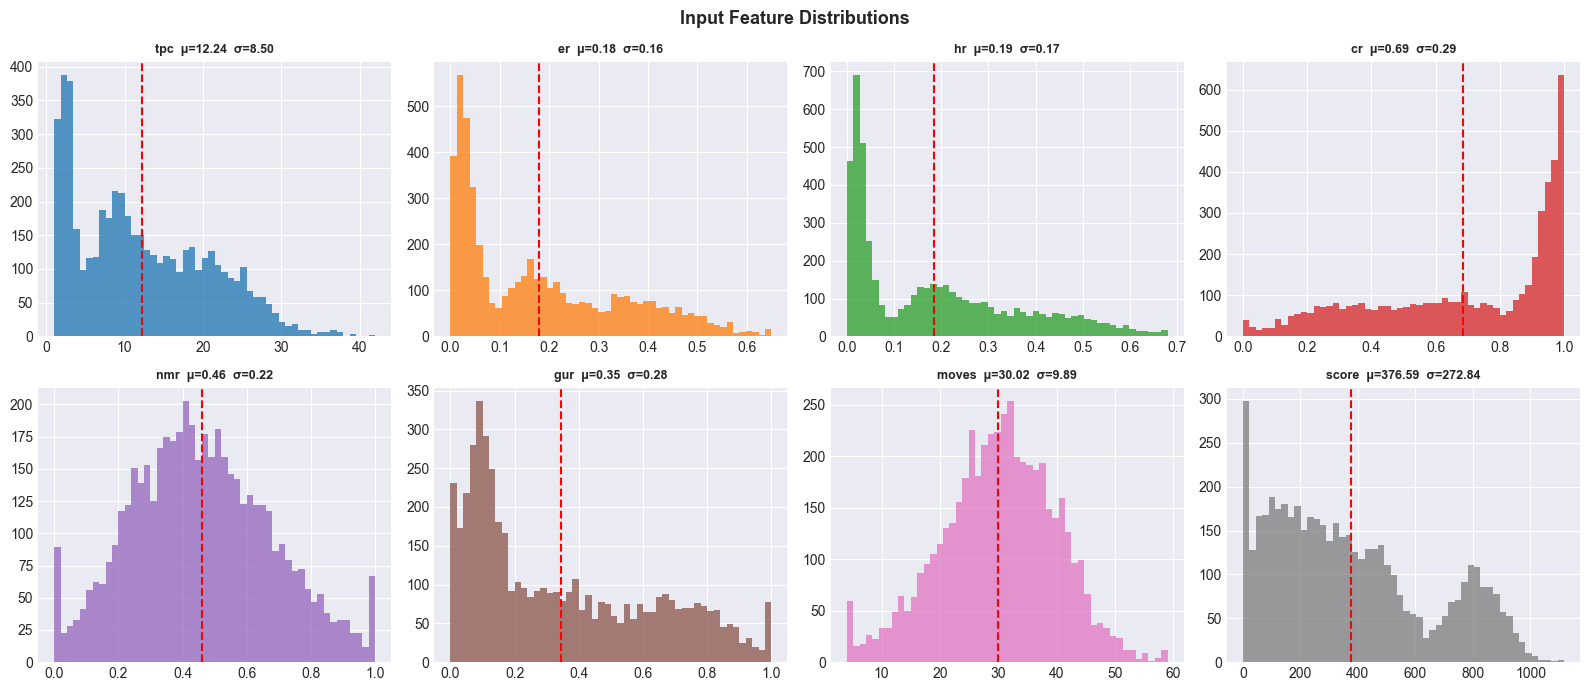

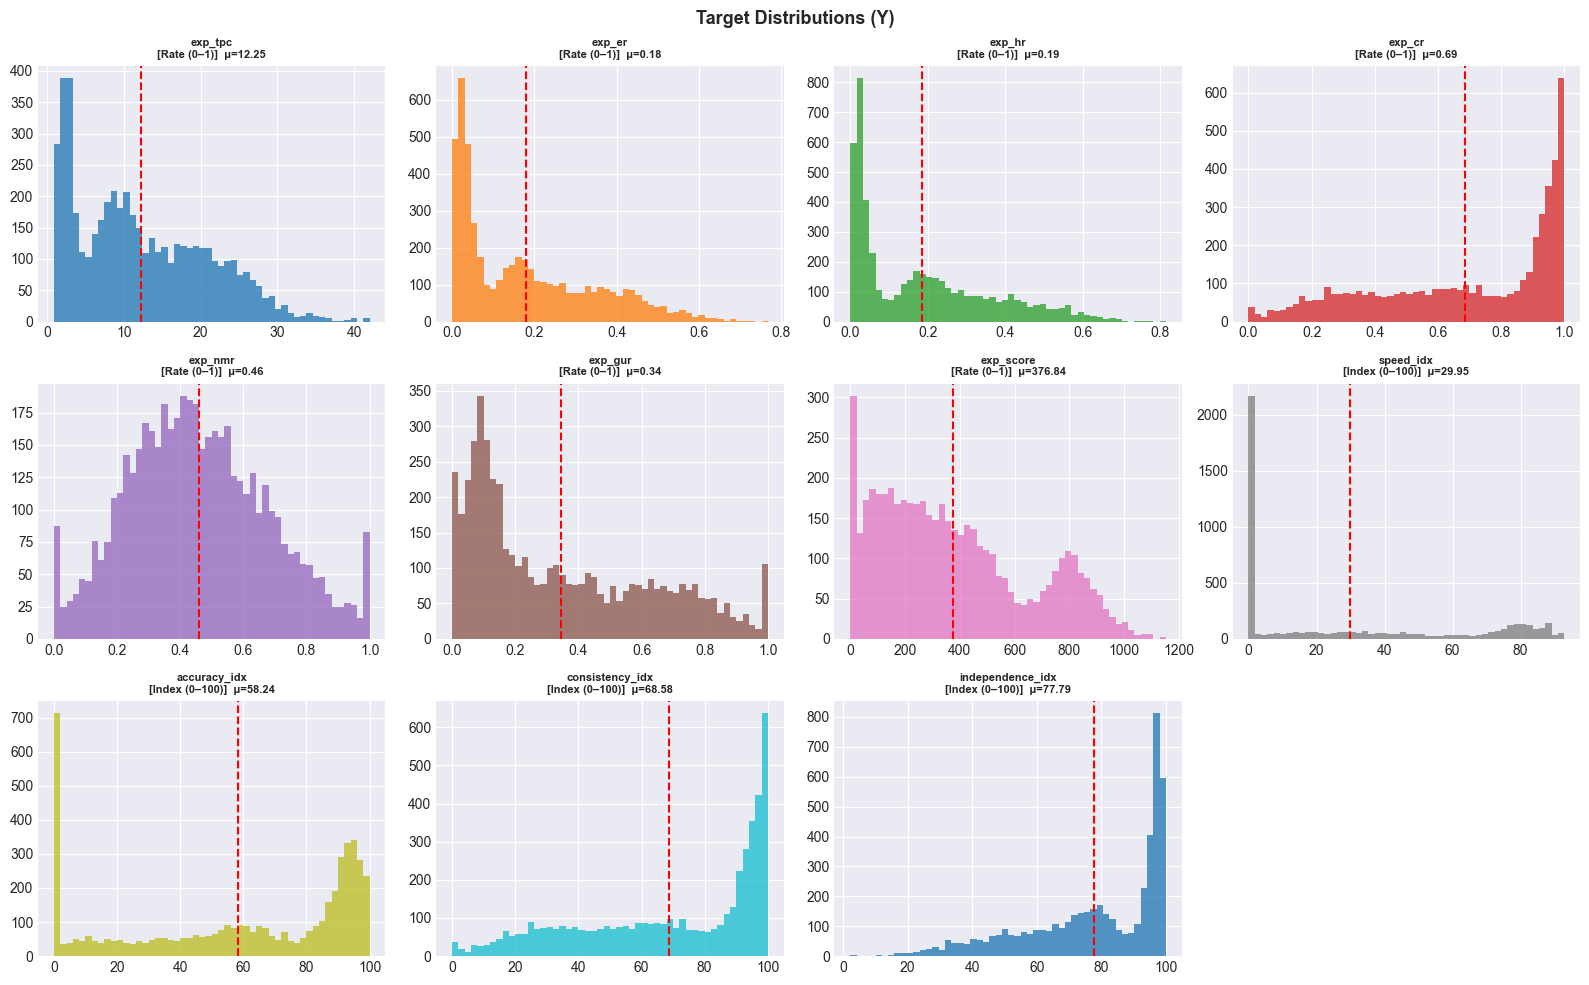

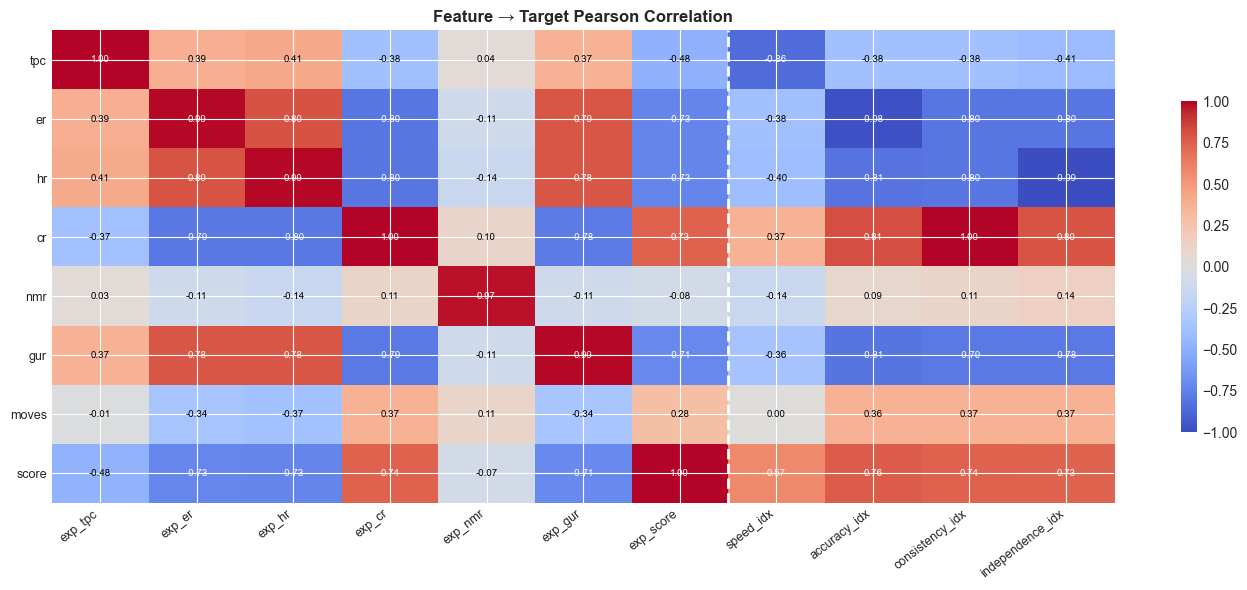


Korelasi tinggi |r| > 0.80 :
  tpc      → exp_tpc                 r=0.995
  tpc      → speed_idx               r=-0.857
  er       → exp_er                  r=0.988
  er       → accuracy_idx            r=-0.976
  hr       → exp_hr                  r=0.989
  hr       → exp_cr                  r=-0.801
  hr       → accuracy_idx            r=-0.813
  hr       → consistency_idx         r=-0.801
  hr       → independence_idx        r=-0.989
  cr       → exp_cr                  r=0.998
  cr       → accuracy_idx            r=0.811
  cr       → consistency_idx         r=0.998
  nmr      → exp_nmr                 r=0.973
  gur      → exp_gur                 r=0.987
  gur      → accuracy_idx            r=-0.806
  score    → exp_score               r=0.995


In [4]:
df_X = pd.DataFrame(X, columns=FEATURE_NAMES)
df_Y = pd.DataFrame(Y, columns=TARGET_NAMES)

print('Input Feature Statistics:')
print(df_X.describe().round(3).to_string())

# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Input Feature Distributions', fontsize=13, fontweight='bold')
for i, (col, ax) in enumerate(zip(FEATURE_NAMES, axes.flat)):
    ax.hist(df_X[col], bins=50, color=f'C{i}', alpha=0.76, edgecolor='none')
    mu, sg = df_X[col].mean(), df_X[col].std()
    ax.axvline(mu, color='red', lw=1.5, ls='--')
    ax.set_title(f'{col}  μ={mu:.2f}  σ={sg:.2f}', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Target distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Target Distributions (Y)', fontsize=13, fontweight='bold')
for i, (col, ax) in enumerate(zip(TARGET_NAMES, axes.flat)):
    grp = 'Rate (0–1)' if i < 7 else 'Index (0–100)'
    ax.hist(df_Y[col], bins=50, color=f'C{i}', alpha=0.76, edgecolor='none')
    mu = df_Y[col].mean()
    ax.axvline(mu, color='red', lw=1.5, ls='--')
    ax.set_title(f'{col}\n[{grp}]  μ={mu:.2f}', fontsize=8, fontweight='bold')
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Feature-Target correlation heatmap
corr_xt = np.zeros((len(FEATURE_NAMES), len(TARGET_NAMES)))
for i, f in enumerate(FEATURE_NAMES):
    for j, t in enumerate(TARGET_NAMES):
        corr_xt[i, j] = np.corrcoef(df_X[f], df_Y[t])[0, 1]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(corr_xt, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_xticks(range(len(TARGET_NAMES)))
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(TARGET_NAMES, rotation=38, ha='right', fontsize=9)
ax.set_yticklabels(FEATURE_NAMES, fontsize=9)
for i in range(len(FEATURE_NAMES)):
    for j in range(len(TARGET_NAMES)):
        val = corr_xt[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(val) > 0.55 else 'black')
ax.set_title('Feature → Target Pearson Correlation', fontsize=12, fontweight='bold')
ax.axvline(6.5, color='white', lw=2, ls='--')   # separator rate vs index targets
plt.tight_layout()
plt.show()

print('\nKorelasi tinggi |r| > 0.80 :')
for i, f in enumerate(FEATURE_NAMES):
    for j, t in enumerate(TARGET_NAMES):
        if abs(corr_xt[i, j]) > 0.80:
            print(f'  {f:<8} → {t:<22}  r={corr_xt[i,j]:.3f}')

## 3. ***Data Split***

Membagi data menjadi:
- 60% *training set*
- 20% *validation set*
- 20% *testing set*

In [5]:
X_tv, X_test, Y_tv, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_tv, Y_tv, test_size=0.25, random_state=42)
# 0.25 × 0.80 = 0.20 dari total

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)
Xva = scaler.transform(X_val)
Xte = scaler.transform(X_test)

print(f'Train : {Xtr.shape}')
print(f'Val   : {Xva.shape}')
print(f'Test  : {Xte.shape}')
print(f'\nScaler mean  : {scaler.mean_.round(3)}')
print(f'Scaler scale : {scaler.scale_.round(3)}')

# Evaluation helpers
def eval_model(model, Xte, Yte, name, verbose=True):
    """Per-output R², RMSE, MAE. Return (mean_r2, list_r2, list_rmse)."""
    Yp    = model.predict(Xte)
    r2s   = [r2_score(Yte[:,i], Yp[:,i])                         for i in range(Yte.shape[1])]
    rmses = [np.sqrt(mean_squared_error(Yte[:,i], Yp[:,i]))      for i in range(Yte.shape[1])]
    maes  = [mean_absolute_error(Yte[:,i], Yp[:,i])              for i in range(Yte.shape[1])]
    mean_r2 = float(np.mean(r2s))
    if verbose:
        print(f'\n{"="*62}')
        print(f'  {name}')
        print(f'  Mean R²: {mean_r2:.4f}')
        print(f'{"-"*62}')
        for n, r, rm, ma in zip(TARGET_NAMES, r2s, rmses, maes):
            tag = '✅' if r >= 0.80 else ('○' if r >= 0.60 else '⚠')
            bar = '█' * max(0, int(r * 24))
            print(f'  {tag} {n:<22}  R²={r:+.3f}  RMSE={rm:.4f}  MAE={ma:.4f}  {bar}')
    return mean_r2, r2s, rmses


def gap_report(model, Xtr, Ytr, Xva, Yva, label):
    """Train vs val R² gap - deteksi overfit/underfit."""
    r2_tr = r2_score(Ytr, model.predict(Xtr), multioutput='uniform_average')
    r2_va = r2_score(Yva, model.predict(Xva), multioutput='uniform_average')
    gap   = r2_tr - r2_va
    status = '⚠ Overfit' if gap > 0.12 else ('⚠ Underfit' if r2_va < 0.60 else '✅ Balanced')
    print(f'{label:<44}  Train={r2_tr:.4f}  Val={r2_va:.4f}  Gap={gap:.4f}  {status}')
    return r2_tr, r2_va, gap


def quick_r2(model, Xva, Yva):
    return r2_score(Yva, model.predict(Xva), multioutput='uniform_average')

Train : (3000, 8)
Val   : (1000, 8)
Test  : (1000, 8)

Scaler mean  : [1.22660e+01 1.82000e-01 1.89000e-01 6.83000e-01 4.61000e-01 3.52000e-01
 2.98470e+01 3.72964e+02]
Scaler scale : [8.5450e+00 1.6400e-01 1.7600e-01 2.9100e-01 2.1700e-01 2.8400e-01
 9.7930e+00 2.7299e+02]


## 4. **Model *Random Forest Regressor* (RFR)**

*Feature importance*: **Gini impurity** (rata-rata dari 11 output estimator).

RFR Baseline                                  Train=0.9971  Val=0.9802  Gap=0.0169  ✅ Balanced


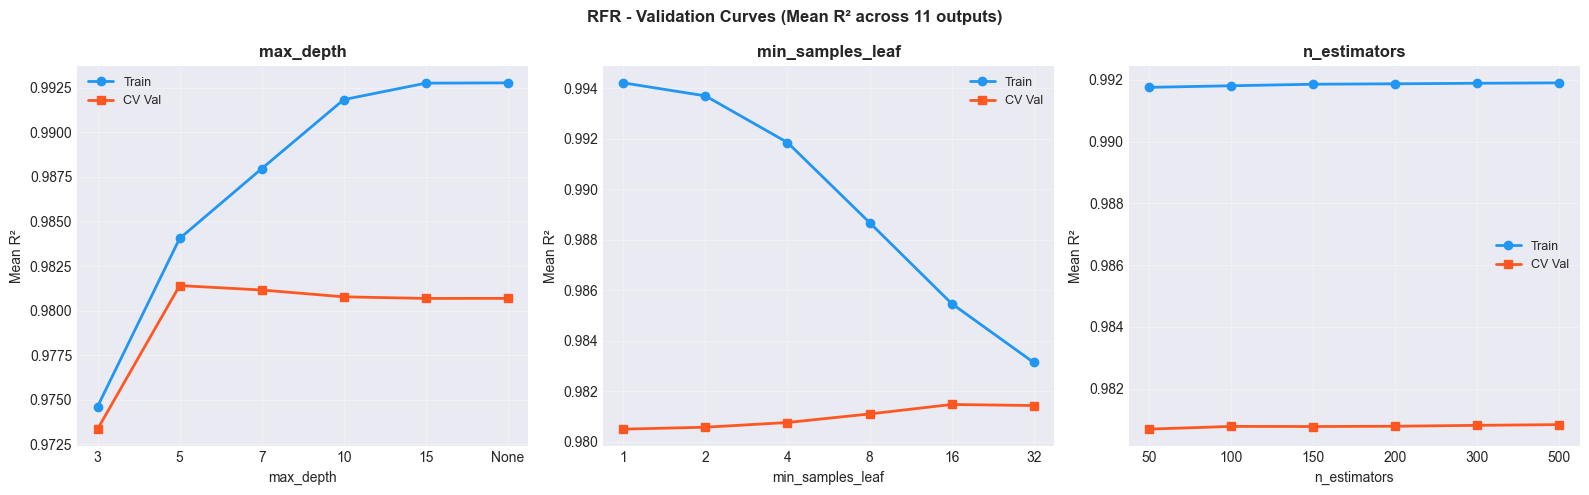

In [6]:
# RFR - Baseline + Validation Curves
rf_base = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), n_jobs=-1)
rf_base.fit(Xtr, Y_train)
gap_report(rf_base, Xtr, Y_train, Xva, Y_val, 'RFR Baseline')

# Validation Curves (manual - lebih fleksibel untuk MultiOutput)
def vc_rf(param_name, param_values, fixed=None):
    """Return (tr_r2_list, va_r2_list) untuk satu hyperparameter."""
    if fixed is None: fixed = {}
    tr_r2, va_r2 = [], []
    for v in param_values:
        kw = {'n_estimators': 120, 'max_depth': 10, 'min_samples_leaf': 4,
              'random_state': 42, 'n_jobs': -1, **fixed, **{param_name: v}}
        m = MultiOutputRegressor(RandomForestRegressor(**kw), n_jobs=-1)
        m.fit(Xtr, Y_train)
        tr_r2.append(quick_r2(m, Xtr, Y_train))
        va_r2.append(quick_r2(m, Xva, Y_val))
    return tr_r2, va_r2

params_vc = {
    'max_depth'         : [3, 5, 7, 10, 15, None],
    'min_samples_leaf'  : [1, 2, 4, 8, 16, 32],
    'n_estimators'      : [50, 100, 150, 200, 300, 500],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFR - Validation Curves (Mean R² across 11 outputs)', fontsize=12, fontweight='bold')

for ax, (pname, pvals) in zip(axes, params_vc.items()):
    tr, va = vc_rf(pname, pvals)
    xlbls = [str(v) if v is not None else 'None' for v in pvals]
    ax.plot(xlbls, tr, 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(xlbls, va, 's-', color='#FF5722', lw=2, label='CV Val')
    ax.set_title(pname, fontweight='bold')
    ax.set_ylabel('Mean R²')
    ax.set_xlabel(pname)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Hyperparameter tuning untuk RFR menggunakan RandomizedSearchCV
param_rf = {
    'estimator__n_estimators':      randint(120, 420),
    'estimator__max_depth':         [None, 8, 10, 12, 15, 20],
    'estimator__min_samples_leaf':  randint(2, 16),
    'estimator__min_samples_split': randint(4, 28),
    'estimator__max_features':      ['sqrt', 0.60, 0.70, 0.80],
    'estimator__bootstrap':         [True, False],
    'estimator__max_samples':       [None, 0.70, 0.80, 0.90],
}

rs_rf = RandomizedSearchCV(
    MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1), n_jobs=-1),
    param_distributions=param_rf,
    n_iter=40, cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2', refit=True, random_state=42, n_jobs=-1, verbose=1)

rs_rf.fit(Xtr, Y_train)
best_rf = rs_rf.best_estimator_

print(f'\nBest CV R²  : {rs_rf.best_score_:.4f}')
print('Best params :')
for k, v in rs_rf.best_params_.items():
    print(f'  {k:<45}: {v}')

r2_rf_tr, r2_rf_va, gap_rf = gap_report(best_rf, Xtr, Y_train, Xva, Y_val, 'RFR (tuned)')
mean_r2_rf, r2_rf_per, rmse_rf_per = eval_model(best_rf, Xva, Y_val, 'RFR Multi-Output (tuned)')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV R²  : 0.9803
Best params :
  estimator__bootstrap                         : True
  estimator__max_depth                         : 12
  estimator__max_features                      : 0.8
  estimator__max_samples                       : 0.9
  estimator__min_samples_leaf                  : 4
  estimator__min_samples_split                 : 25
  estimator__n_estimators                      : 377
RFR (tuned)                                   Train=0.9877  Val=0.9812  Gap=0.0065  ✅ Balanced

  RFR Multi-Output (tuned)
  Mean R²: 0.9812
--------------------------------------------------------------
  ✅ exp_tpc                 R²=+0.989  RMSE=0.9084  MAE=0.5819  ███████████████████████
  ✅ exp_er                  R²=+0.978  RMSE=0.0245  MAE=0.0149  ███████████████████████
  ✅ exp_hr                  R²=+0.976  RMSE=0.0260  MAE=0.0157  ███████████████████████
  ✅ exp_cr                  R²=+0.994  RMSE=0.0216  MAE=0.0170  ██

## 5. **Model *Histogram Gradient Boosting* (HistGBR)**

Keunggulan: regularisasi `l2`, toleransi *missing values*, lebih cepat dari GBM biasa.  
*Feature importance*: *Permutation Importance* (tidak ada *native* `feature_importances_`).

HistGBR Baseline                              Train=0.9943  Val=0.9794  Gap=0.0149  ✅ Balanced


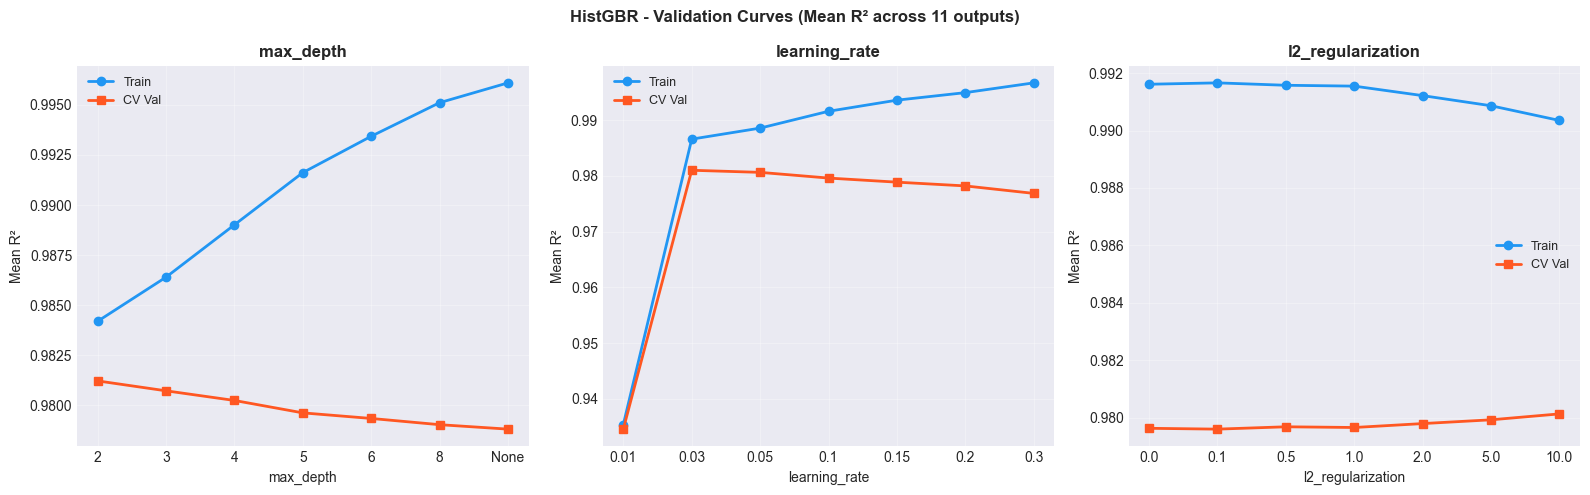

In [8]:
# HistGBR - Baseline + Validation Curves
hgb_base = MultiOutputRegressor(
    HistGradientBoostingRegressor(early_stopping=False, random_state=42), n_jobs=-1)
hgb_base.fit(Xtr, Y_train)
gap_report(hgb_base, Xtr, Y_train, Xva, Y_val, 'HistGBR Baseline')

def vc_hgb(param_name, param_values, fixed=None):
    if fixed is None: fixed = {}
    tr_r2, va_r2 = [], []
    for v in param_values:
        kw = {'max_iter': 150, 'max_depth': 5, 'learning_rate': 0.1,
              'early_stopping': False, 'random_state': 42,
              **fixed, **{param_name: v}}
        m = MultiOutputRegressor(HistGradientBoostingRegressor(**kw), n_jobs=-1)
        m.fit(Xtr, Y_train)
        tr_r2.append(quick_r2(m, Xtr, Y_train))
        va_r2.append(quick_r2(m, Xva, Y_val))
    return tr_r2, va_r2

params_hgb_vc = {
    'max_depth'          : [2, 3, 4, 5, 6, 8, None],
    'learning_rate'      : [0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30],
    'l2_regularization'  : [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HistGBR - Validation Curves (Mean R² across 11 outputs)', fontsize=12, fontweight='bold')

for ax, (pname, pvals) in zip(axes, params_hgb_vc.items()):
    tr, va = vc_hgb(pname, pvals)
    xlbls = [str(v) if v is not None else 'None' for v in pvals]
    ax.plot(xlbls, tr, 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(xlbls, va, 's-', color='#FF5722', lw=2, label='CV Val')
    ax.set_title(pname, fontweight='bold')
    ax.set_ylabel('Mean R²')
    ax.set_xlabel(pname)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Hyperparameter tuning untuk HistGBR mengunakan RandomizedSearchCV
param_hgb = {
    'estimator__max_iter':           [100, 150, 200, 300, 400],
    'estimator__max_depth':          [3, 4, 5, 6, 8],
    'estimator__learning_rate':      uniform(0.02, 0.18),
    'estimator__l2_regularization':  uniform(0.01, 3.0),
    'estimator__min_samples_leaf':   randint(8, 45),
    'estimator__max_leaf_nodes':     [20, 31, 40, 50, 63, None],
    'estimator__max_features':       [1.0, 0.80, 0.90],
}

rs_hgb = RandomizedSearchCV(
    MultiOutputRegressor(
        HistGradientBoostingRegressor(early_stopping=False, random_state=42), n_jobs=-1),
    param_distributions=param_hgb,
    n_iter=40, cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2', refit=True, random_state=42, n_jobs=-1, verbose=1)

rs_hgb.fit(Xtr, Y_train)
best_hgb = rs_hgb.best_estimator_

print(f'\nBest CV R²  : {rs_hgb.best_score_:.4f}')
print('Best params :')
for k, v in rs_hgb.best_params_.items():
    print(f'  {k:<45}: {v}')

r2_hgb_tr, r2_hgb_va, gap_hgb = gap_report(best_hgb, Xtr, Y_train, Xva, Y_val, 'HistGBR (tuned)')
mean_r2_hgb, r2_hgb_per, rmse_hgb_per = eval_model(best_hgb, Xva, Y_val, 'HistGBR Multi-Output (tuned)')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV R²  : 0.9806
Best params :
  estimator__l2_regularization                 : 2.8387291117375573
  estimator__learning_rate                     : 0.07817652776373595
  estimator__max_depth                         : 3
  estimator__max_features                      : 1.0
  estimator__max_iter                          : 100
  estimator__max_leaf_nodes                    : 31
  estimator__min_samples_leaf                  : 19
HistGBR (tuned)                               Train=0.9845  Val=0.9813  Gap=0.0032  ✅ Balanced

  HistGBR Multi-Output (tuned)
  Mean R²: 0.9813
--------------------------------------------------------------
  ✅ exp_tpc                 R²=+0.989  RMSE=0.8828  MAE=0.5819  ███████████████████████
  ✅ exp_er                  R²=+0.977  RMSE=0.0248  MAE=0.0150  ███████████████████████
  ✅ exp_hr                  R²=+0.976  RMSE=0.0263  MAE=0.0158  ███████████████████████
  ✅ exp_cr                  R²=+

## 6. ***Model Comparation***

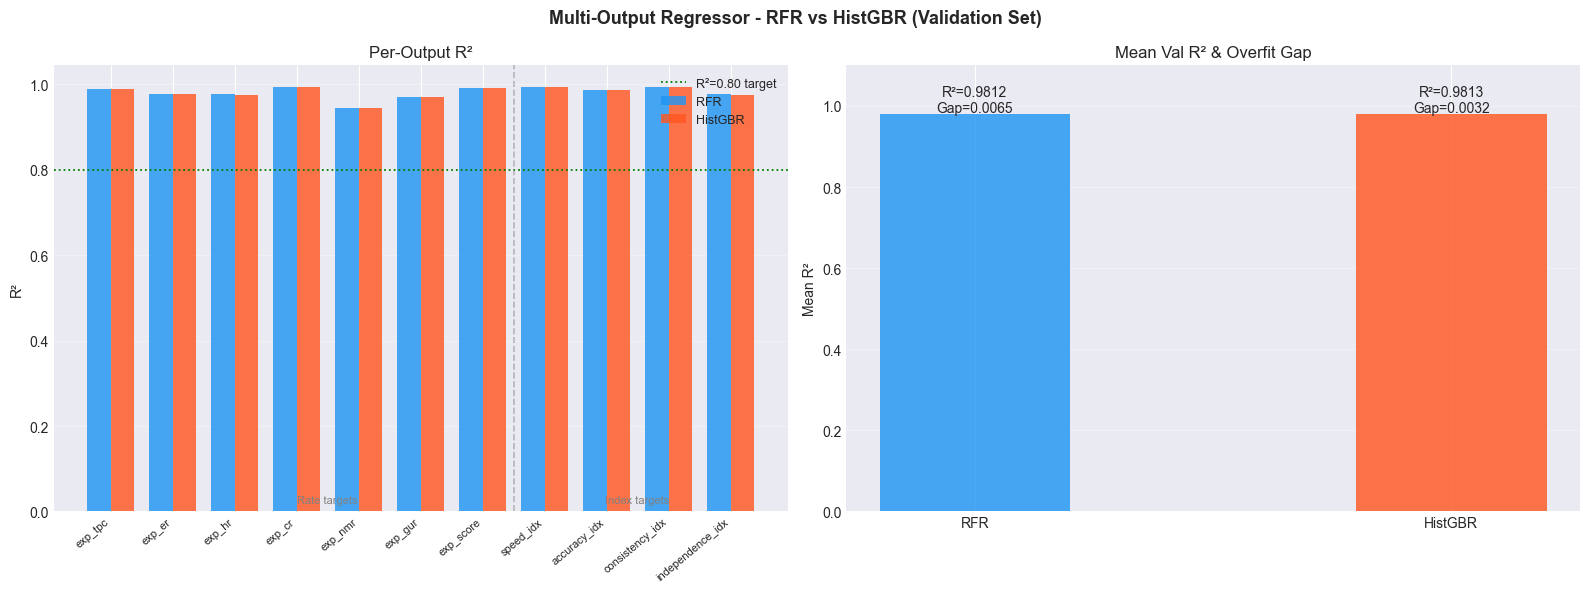

🏆 Winner (val): HistGBR  (Mean R²=0.9813)


In [10]:
# RFR vs HistGBR - Perbandingan Visual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Multi-Output Regressor - RFR vs HistGBR (Validation Set)', fontsize=13, fontweight='bold')

# Per-output R² bar chart
x = np.arange(len(TARGET_NAMES)); w = 0.38
axes[0].bar(x-w/2, r2_rf_per,  w, label='RFR', color='#2196F3', alpha=0.82)
axes[0].bar(x+w/2, r2_hgb_per, w, label='HistGBR', color='#FF5722', alpha=0.82)
axes[0].axhline(0.80, color='green', lw=1.3, ls=':', label='R²=0.80 target')
axes[0].axhline(0,    color='black', lw=0.6, ls='--')
axes[0].axvline(6.5,  color='gray',  lw=1.2, ls='--', alpha=0.5)  # separator
axes[0].text(3.5, 0.02, 'Rate targets', ha='center', fontsize=8, color='gray')
axes[0].text(8.5, 0.02, 'Index targets', ha='center', fontsize=8, color='gray')
axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGET_NAMES, rotation=40, ha='right', fontsize=8)
axes[0].set_ylabel('R²'); axes[0].set_title('Per-Output R²')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Summary: mean R² + gap
models    = ['RFR', 'HistGBR']
val_r2s   = [mean_r2_rf,         mean_r2_hgb]
gaps      = [r2_rf_tr-r2_rf_va,  r2_hgb_tr-r2_hgb_va]
colors    = ['#2196F3', '#FF5722']

b = axes[1].bar(models, val_r2s, color=colors, alpha=0.82, width=0.4)
for bar, g, r in zip(b, gaps, val_r2s):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'R²={r:.4f}\nGap={g:.4f}', ha='center', fontsize=10)
axes[1].set_ylim(0, min(1.1, max(val_r2s)+0.15))
axes[1].set_ylabel('Mean R²'); axes[1].set_title('Mean Val R² & Overfit Gap')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Pick winner
winner     = 'RFR' if mean_r2_rf >= mean_r2_hgb else 'HistGBR'
best_model = best_rf  if winner == 'RFR' else best_hgb
best_r2    = max(mean_r2_rf, mean_r2_hgb)
best_per   = r2_rf_per if winner == 'RFR' else r2_hgb_per

print(f'🏆 Winner (val): {winner}  (Mean R²={best_r2:.4f})')

## 7. ***Learning Curves***

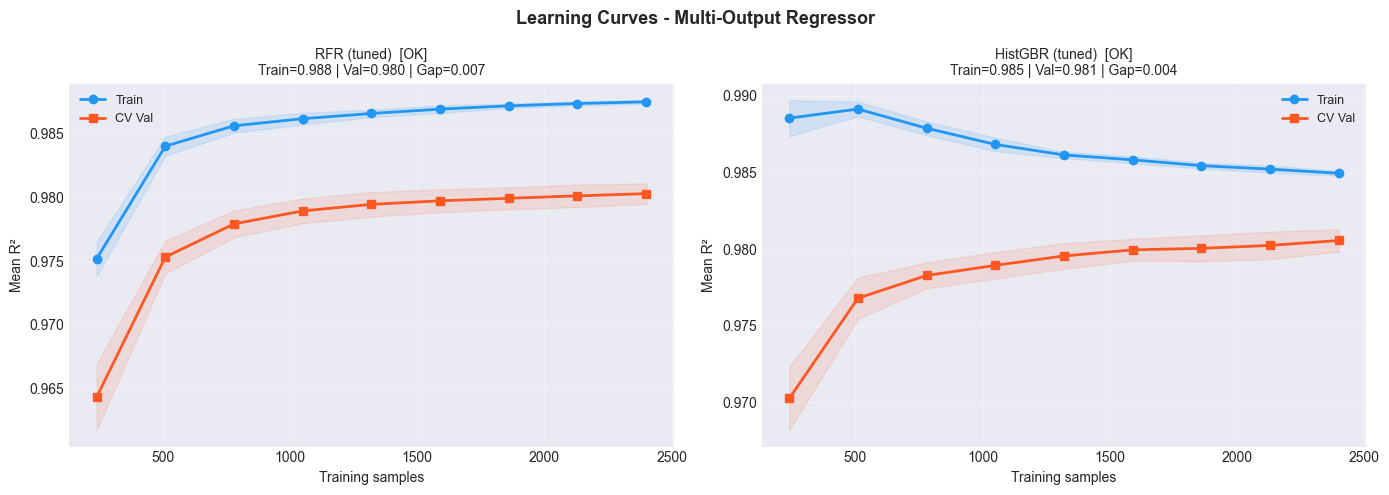

In [11]:
# Learning Curves untuk kedua model
def plot_lc(estimator, X, y, title, ax=None):
    kf    = KFold(n_splits=5, shuffle=True, random_state=42)
    sizes = np.linspace(0.10, 1.0, 9)
    tr_sz, tr_sc, va_sc = learning_curve(
        estimator, X, y,
        train_sizes=sizes, cv=kf,
        scoring='r2', n_jobs=-1,
        shuffle=True, random_state=42)

    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    va_m, va_s = va_sc.mean(1), va_sc.std(1)
    gap = tr_m[-1] - va_m[-1]

    own = ax is None
    if own: _, ax = plt.subplots(figsize=(7, 5))

    ax.plot(tr_sz, tr_m, 'o-', color='#2196F3', lw=2, label='Train')
    ax.fill_between(tr_sz, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='#2196F3')
    ax.plot(tr_sz, va_m, 's-', color='#FF5722', lw=2, label='CV Val')
    ax.fill_between(tr_sz, va_m-va_s, va_m+va_s, alpha=0.12, color='#FF5722')

    status = 'Overfit' if gap > 0.12 else ('Underfit' if va_m[-1] < 0.60 else 'OK')
    ax.set_title(f'{title}  [{status}]\nTrain={tr_m[-1]:.3f} | Val={va_m[-1]:.3f} | Gap={gap:.3f}',
                 fontsize=10)
    ax.set_xlabel('Training samples'); ax.set_ylabel('Mean R²')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    if own: 
        plt.tight_layout()
        plt.show()
    return tr_m[-1], va_m[-1], gap


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves - Multi-Output Regressor', fontsize=13, fontweight='bold')
plot_lc(best_rf,  Xtr, Y_train, 'RFR (tuned)',  ax=axes[0])
plot_lc(best_hgb, Xtr, Y_train, 'HistGBR (tuned)', ax=axes[1])
plt.tight_layout()
plt.show()

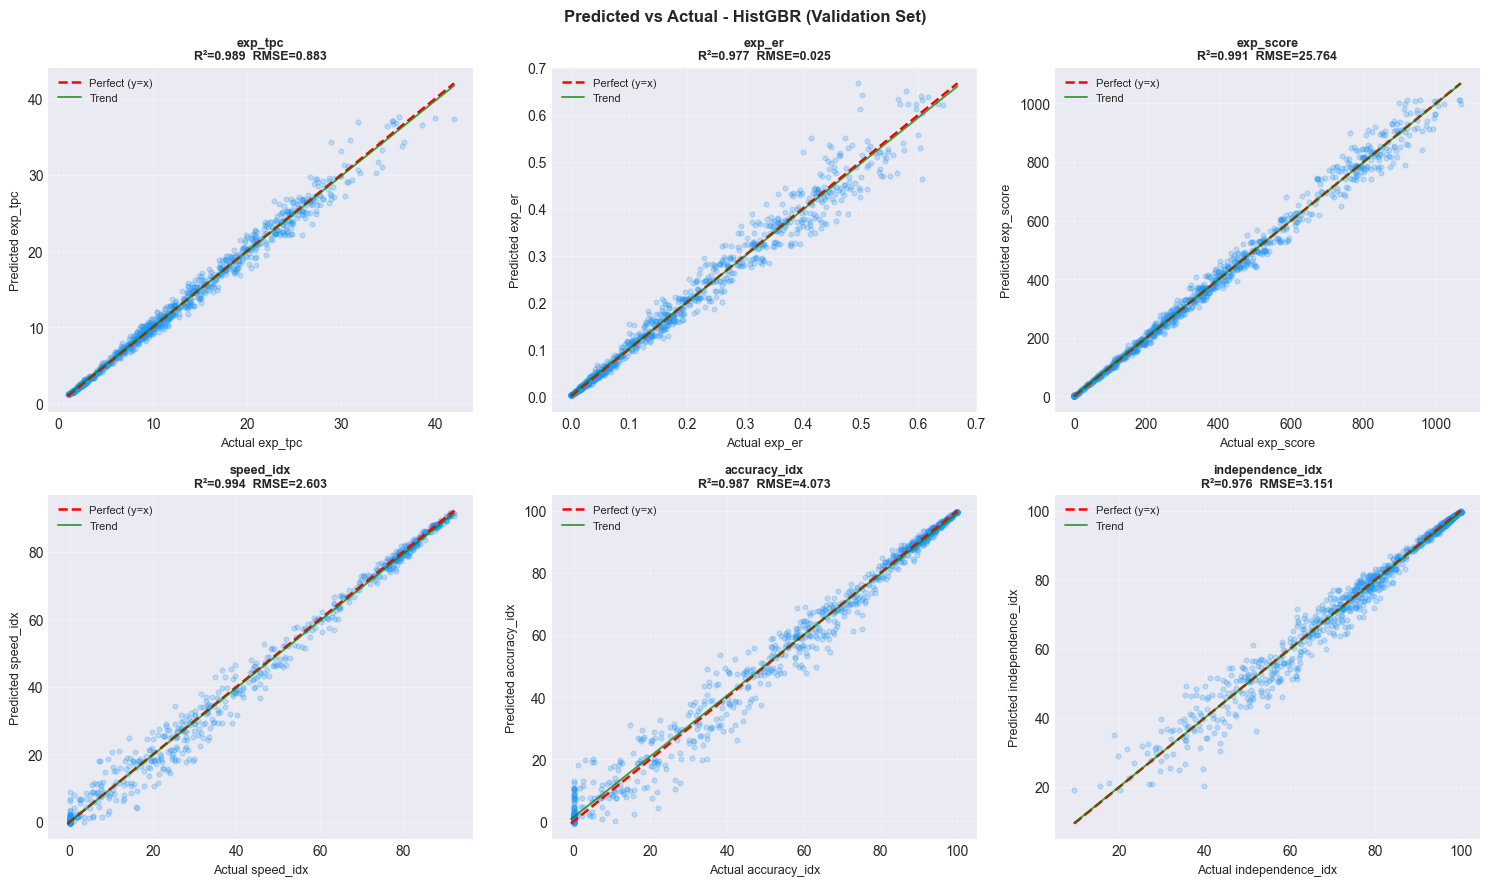

In [12]:
# PREDICTED vs ACTUAL - Scatter Plots (sample 6 outputs)
Yp_va = best_model.predict(Xva)

sample_targets = [
    'exp_tpc', 'exp_er', 'exp_score',
    'speed_idx', 'accuracy_idx', 'independence_idx'
]
sample_idx = [TARGET_NAMES.index(t) for t in sample_targets]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(f'Predicted vs Actual - {winner} (Validation Set)',
             fontsize=12, fontweight='bold')

for ax, i, name in zip(axes.flat, sample_idx, sample_targets):
    y_true = Y_val[:, i]
    y_pred = Yp_va[:, i]
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    ax.scatter(y_true, y_pred, alpha=0.22, s=12, color='#2196F3', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.8, label='Perfect (y=x)')

    # Trend line
    z = np.polyfit(y_true, y_pred, 1)
    p = np.poly1d(z)
    xs = np.linspace(lo, hi, 100)
    ax.plot(xs, p(xs), 'g-', lw=1.4, alpha=0.7, label='Trend')

    ax.set_xlabel(f'Actual {name}', fontsize=9)
    ax.set_ylabel(f'Predicted {name}', fontsize=9)
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.3f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

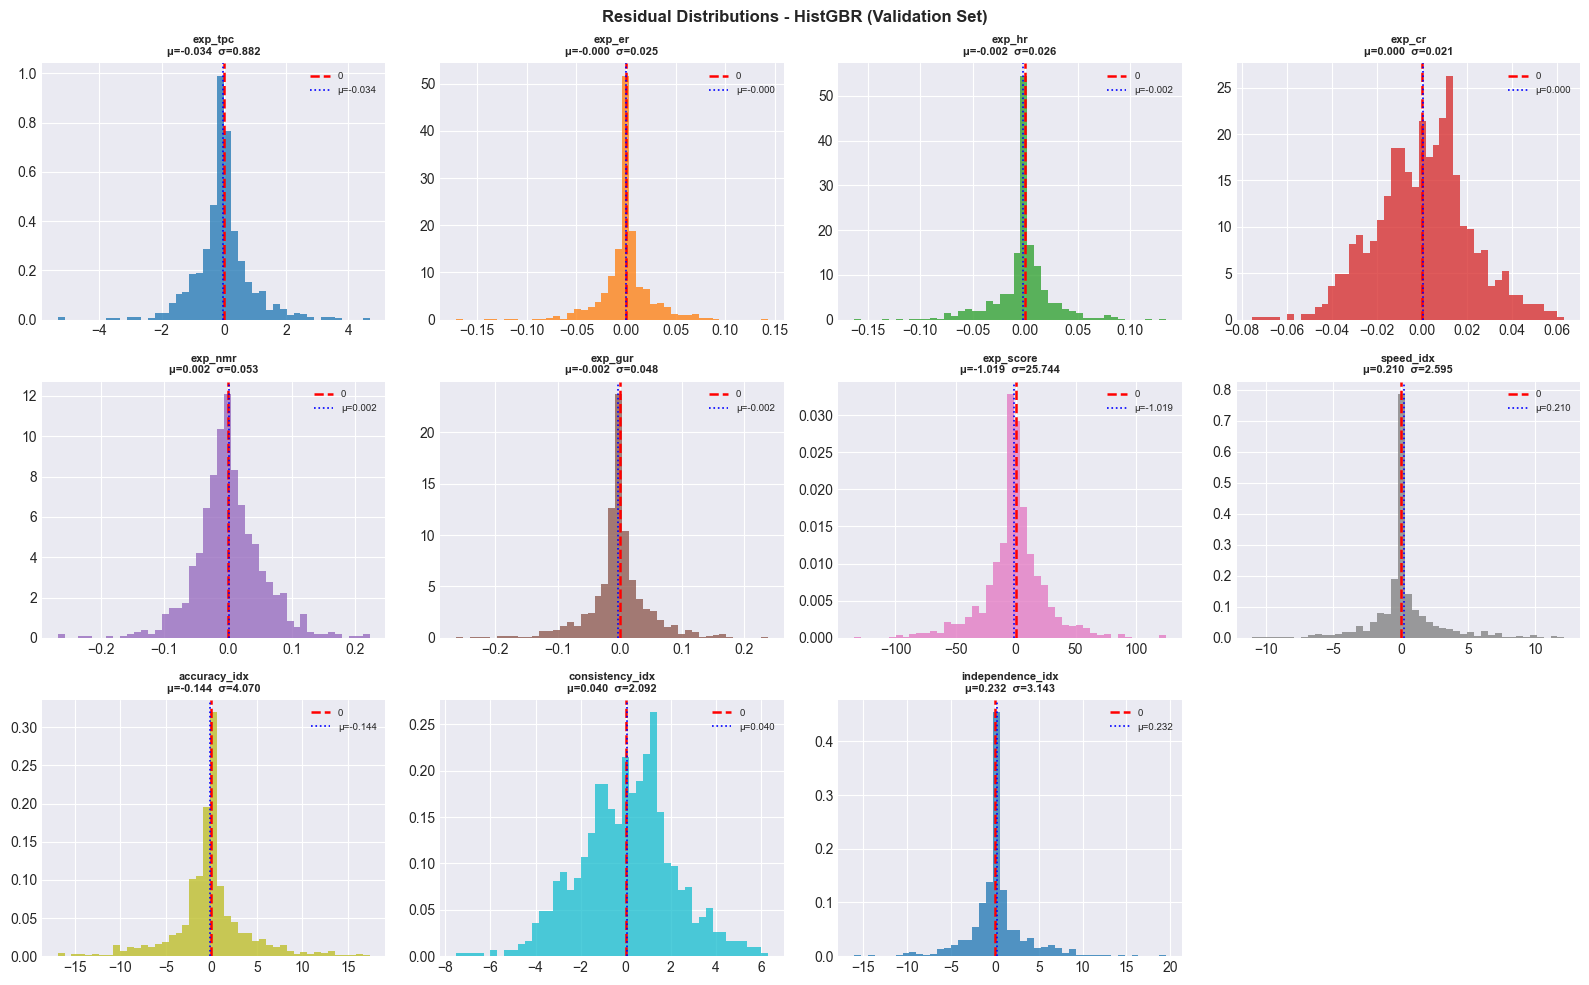

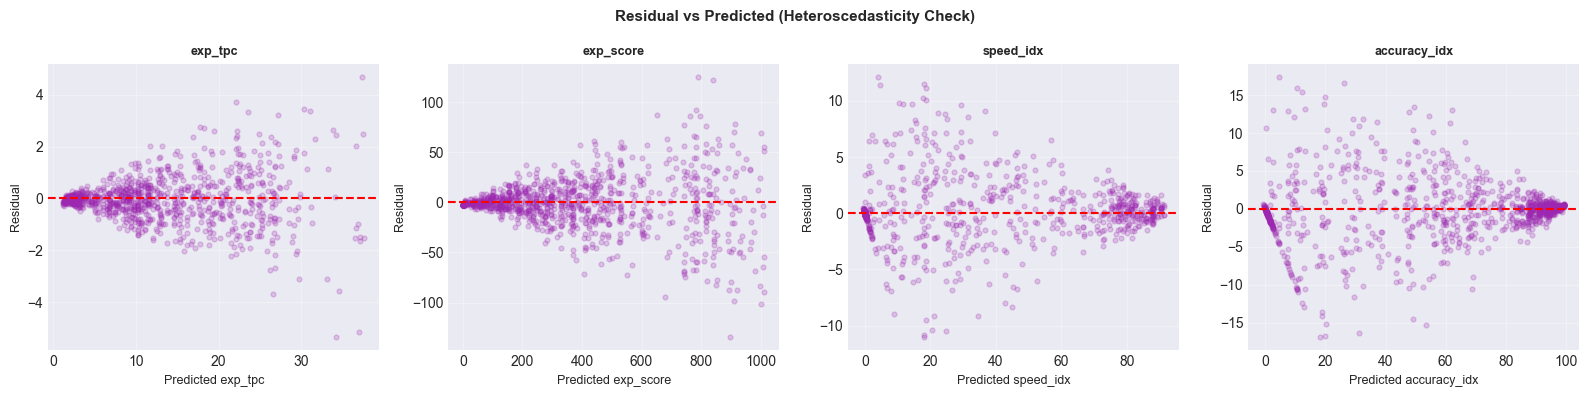

Residual Summary:
Target                       Mean        Std    Max|Res|
--------------------------------------------------------
✅ exp_tpc                   -0.0336     0.8821      5.3423
✅ exp_er                    -0.0004     0.0248      0.1717
✅ exp_hr                    -0.0019     0.0262      0.1629
✅ exp_cr                     0.0004     0.0209      0.0754
✅ exp_nmr                    0.0017     0.0534      0.2679
✅ exp_gur                   -0.0024     0.0484      0.2636
✅ exp_score                 -1.0194    25.7442    134.5938
✅ speed_idx                  0.2098     2.5948     12.1473
✅ accuracy_idx              -0.1436     4.0704     17.4129
✅ consistency_idx            0.0395     2.0924      7.5364
✅ independence_idx           0.2323     3.1427     19.5449


In [13]:
# RESIDUAL ANALYSIS
# Residual ideal: terpusat di 0, distribusi normal

residuals = Y_val - Yp_va   # shape (n_val, 11)

# Residual distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle(f'Residual Distributions - {winner} (Validation Set)', fontsize=12, fontweight='bold')

for i, (ax, name) in enumerate(zip(axes.flat, TARGET_NAMES)):
    res = residuals[:, i]
    ax.hist(res, bins=45, color=f'C{i}', alpha=0.76, edgecolor='none', density=True)
    ax.axvline(0,       color='red',    lw=1.8, ls='--', label='0')
    ax.axvline(res.mean(), color='blue', lw=1.2, ls=':', label=f'μ={res.mean():.3f}')
    ax.set_title(f'{name}\nμ={res.mean():.3f}  σ={res.std():.3f}', fontsize=8, fontweight='bold')
    ax.legend(fontsize=7)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Residual vs Predicted (heteroscedasticity check)
sample_tgt = ['exp_tpc', 'exp_score', 'speed_idx', 'accuracy_idx']
sample_idx = [TARGET_NAMES.index(t) for t in sample_tgt]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Residual vs Predicted (Heteroscedasticity Check)', fontsize=11, fontweight='bold')

for ax, i, name in zip(axes, sample_idx, sample_tgt):
    ax.scatter(Yp_va[:, i], residuals[:, i], alpha=0.22, s=12, color='#9C27B0', rasterized=True)
    ax.axhline(0, color='red', lw=1.5, ls='--')
    ax.set_xlabel(f'Predicted {name}', fontsize=9)
    ax.set_ylabel('Residual', fontsize=9)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print('Residual Summary:')
print(f'{"Target":<22}  {"Mean":>9}  {"Std":>9}  {"Max|Res|":>10}')
print('-' * 56)
for i, name in enumerate(TARGET_NAMES):
    res = residuals[:, i]
    bias  = '✅' if abs(res.mean()) < 0.05 * (Y_val[:, i].max() - Y_val[:, i].min() + 1e-9) else '⚠'
    print(f'{bias} {name:<22}  {res.mean():>9.4f}  {res.std():>9.4f}  {np.abs(res).max():>10.4f}')

## 8. ***Feature Importance***

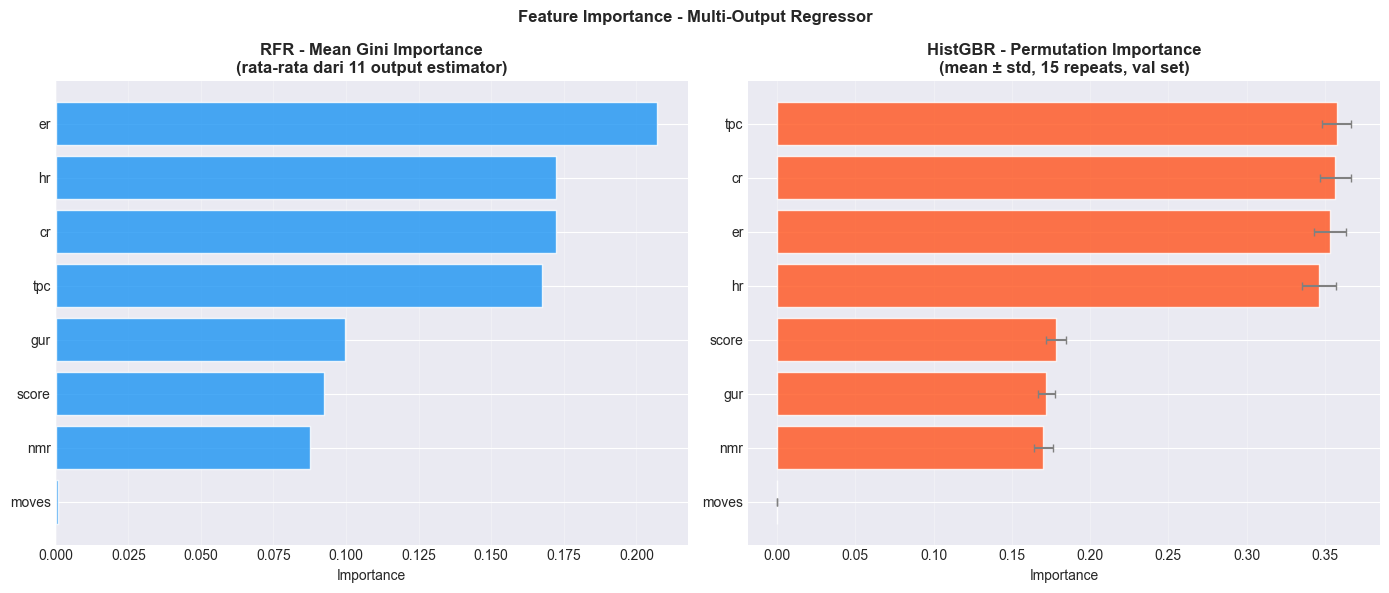

Feature Importance:
         RFR_Gini  HistGBR_Perm  HistGBR_Perm_std
Feature                                          
er         0.2073        0.3534            0.0103
hr         0.1724        0.3463            0.0107
cr         0.1724        0.3566            0.0098
tpc        0.1674        0.3576            0.0092
gur        0.0998        0.1721            0.0053
score      0.0922        0.1783            0.0066
nmr        0.0877        0.1702            0.0059
moves      0.0009        0.0000            0.0000


In [14]:
# RFR: mean Gini across 11 output-specific RF estimators
# HistGBR: permutation importance on validation set

# RFR native importance
imp_rf = np.mean(
    [e.feature_importances_ for e in best_rf.estimators_], axis=0)

# HistGBR permutation importance
perm = permutation_importance(
    best_hgb, Xva, Y_val,
    n_repeats=15, random_state=42, n_jobs=-1)
imp_hgb = perm.importances_mean
imp_hgb_std = perm.importances_std

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance - Multi-Output Regressor', fontsize=12, fontweight='bold')

def _bar_h(ax, vals, errs, labels, title, color):
    idx = np.argsort(vals)
    ax.barh(
        [labels[i] for i in idx], [vals[i] for i in idx],
        xerr=[errs[i] for i in idx] if errs is not None else None,
        color=color, alpha=0.82, edgecolor='white',
        ecolor='gray', capsize=3)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

_bar_h(axes[0], imp_rf,  None,         FEATURE_NAMES,
       'RFR - Mean Gini Importance\n(rata-rata dari 11 output estimator)', '#2196F3')
_bar_h(axes[1], imp_hgb, imp_hgb_std, FEATURE_NAMES,
       'HistGBR - Permutation Importance\n(mean ± std, 15 repeats, val set)', '#FF5722')

plt.tight_layout()
plt.show()

# Table
imp_df = pd.DataFrame({
    'Feature':    FEATURE_NAMES,
    'RFR_Gini':   imp_rf.round(4),
    'HistGBR_Perm':   imp_hgb.round(4),
    'HistGBR_Perm_std': imp_hgb_std.round(4),
}).set_index('Feature').sort_values('RFR_Gini', ascending=False)

print('Feature Importance:')
print(imp_df.to_string())

## 9. ***Evaluation***


  HistGBR - FINAL TEST
  Mean R²: 0.9825
--------------------------------------------------------------
  ✅ exp_tpc                 R²=+0.989  RMSE=0.8853  MAE=0.5815  ███████████████████████
  ✅ exp_er                  R²=+0.974  RMSE=0.0264  MAE=0.0151  ███████████████████████
  ✅ exp_hr                  R²=+0.980  RMSE=0.0244  MAE=0.0145  ███████████████████████
  ✅ exp_cr                  R²=+0.995  RMSE=0.0202  MAE=0.0163  ███████████████████████
  ✅ exp_nmr                 R²=+0.952  RMSE=0.0492  MAE=0.0362  ██████████████████████
  ✅ exp_gur                 R²=+0.974  RMSE=0.0444  MAE=0.0276  ███████████████████████
  ✅ exp_score               R²=+0.989  RMSE=28.3910  MAE=18.3696  ███████████████████████
  ✅ speed_idx               R²=+0.995  RMSE=2.4418  MAE=1.3514  ███████████████████████
  ✅ accuracy_idx            R²=+0.984  RMSE=4.4006  MAE=2.4903  ███████████████████████
  ✅ consistency_idx         R²=+0.995  RMSE=2.0222  MAE=1.6346  ███████████████████████
  ✅ independen

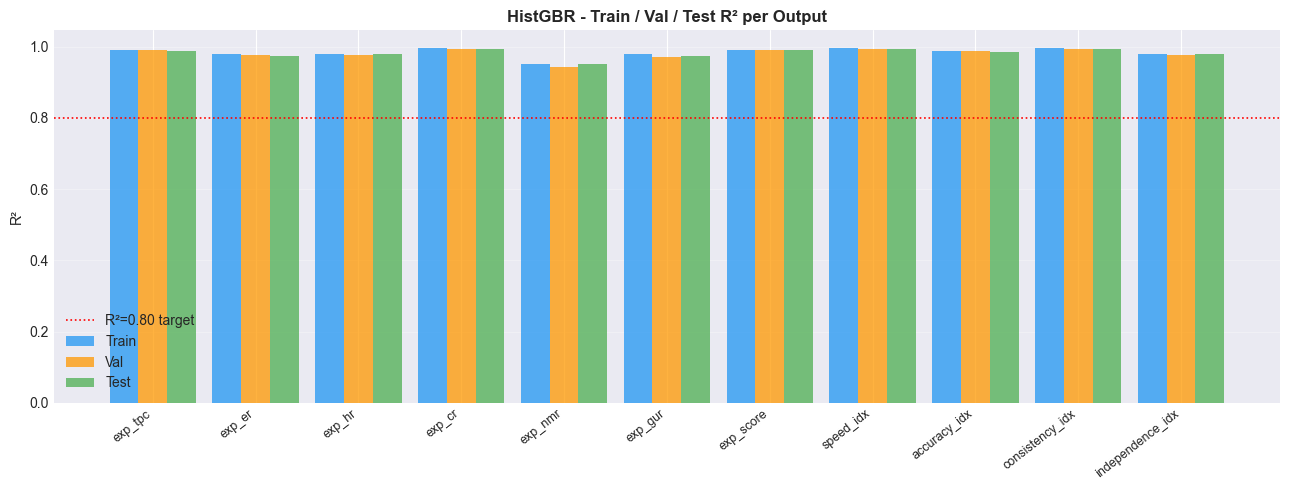

In [15]:
# FINAL TEST SET EVALUATION (held-out - tidak pernah disentuh)
r2_tr_final = r2_score(Y_train, best_model.predict(Xtr), multioutput='uniform_average')
r2_va_final = r2_score(Y_val,   best_model.predict(Xva), multioutput='uniform_average')
r2_te_final, r2_te_per, rmse_te_per = eval_model(
    best_model, Xte, Y_test, f'{winner} - FINAL TEST', verbose=True)

gap_cv_te = r2_tr_final - r2_te_final

print(f'\n{"-"*45}')
print(f'  Train R²      : {r2_tr_final:.4f}')
print(f'  Val   R²      : {r2_va_final:.4f}')
print(f'  Test  R²      : {r2_te_final:.4f}')
print(f'  Train-Test Gap: {gap_cv_te:.4f}')
print(f'  Overfit check : {"✅ PASS" if gap_cv_te <= 0.12 else "⚠  FAIL"}')
print(f'  Underfit check: {"✅ PASS" if r2_te_final >= 0.60 else "⚠  FAIL"}')

# Visualisasi train/val/test R² per output
r2_val_best = [r2_score(Y_val[:,i], best_model.predict(Xva)[:,i]) for i in range(11)]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(TARGET_NAMES)); w = 0.28
ax.bar(x-w, [r2_score(Y_train[:,i], best_model.predict(Xtr)[:,i]) for i in range(11)],
       w, label='Train', color='#2196F3', alpha=0.75)
ax.bar(x,   r2_val_best, w, label='Val',   color='#FF9800', alpha=0.75)
ax.bar(x+w, r2_te_per,   w, label='Test',  color='#4CAF50', alpha=0.75)
ax.axhline(0.80, color='red', lw=1.2, ls=':', label='R²=0.80 target')
ax.axhline(0,    color='black', lw=0.5, ls='--')
ax.set_xticks(x)
ax.set_xticklabels(TARGET_NAMES, rotation=38, ha='right', fontsize=9)
ax.set_ylabel('R²'); ax.set_title(f'{winner} - Train / Val / Test R² per Output', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. ***Save & Verify Model***

In [16]:
# Save model + scaler + metadata ke PKL
PKL_DIR = Path("Files")
PKL_DIR.mkdir(parents=True, exist_ok=True)

def save_pkl(name, obj):
    path = PKL_DIR / name
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size = path.stat().st_size / 1024
    print(f'Model {name:<20} ({size:.1f} KB)')

# Menyimpan model terbaik, scaler, dan metrik R² ke file PKL
save_pkl('Performance_Prediction.pkl', {
    'model':  best_model,
    'scaler': scaler,
    'r2':     r2_te_final,
})

Model Performance_Prediction.pkl (1780.1 KB)


In [17]:
# Verification
with open(PKL_DIR / 'Performance_Prediction.pkl', 'rb') as f:
    pkg = pickle.load(f)

sample_x  = pkg['scaler'].transform(X_test[:5])
sample_y  = pkg['model'].predict(sample_x)

print(f'Output shape     : {sample_y.shape}  (5 samples × 11 targets)')
print(f'speed_idx        : {sample_y[:, 7].round(1)}')
print(f'accuracy_idx     : {sample_y[:, 8].round(1)}')
print(f'consistency_idx  : {sample_y[:, 9].round(1)}')
print(f'independence_idx : {sample_y[:,10].round(1)}')

Output shape     : (5, 11)  (5 samples × 11 targets)
speed_idx        : [78.   0.5 22.1 75.7 88. ]
accuracy_idx     : [95.6 13.4 37.8 95.9 95.6]
consistency_idx  : [95.7 62.8 87.6 95.3 98.9]
independence_idx : [99.6 57.8 83.5 98.3 98.1]
